<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/tugas1bJobsheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [61]:
# mengubah semua atribut nominal (sex, smoker, region) menjadi numerik
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

In [57]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (a):", model.intercept_)
print("Coefficients (b):", model.coef_)

Intercept (a): -11931.21905032666
Coefficients (b): [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]


In [58]:
y_pred = model.predict(X_test)
# menghitung RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Square Error (RMSE):", rmse)

Root Mean Square Error (RMSE): 5796.284659276273


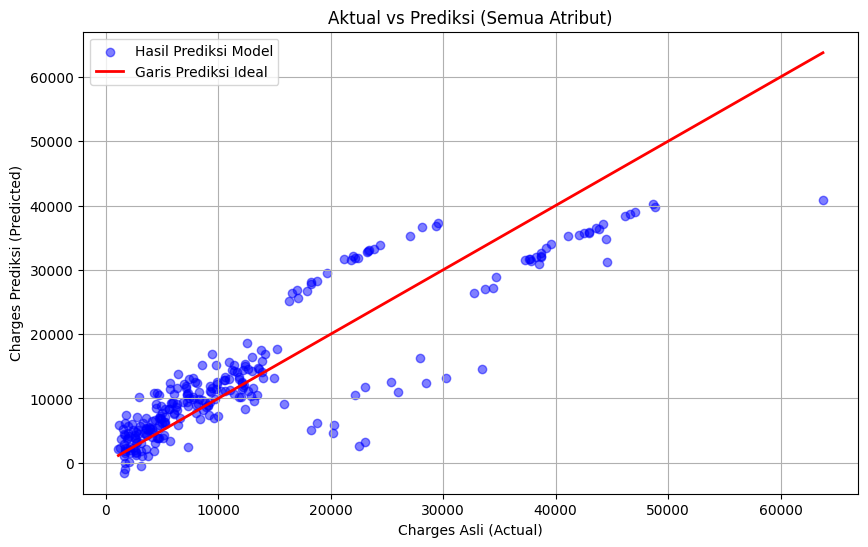

In [63]:
plt.figure(figsize=(10, 6))

# plot scatter: sumbu x adalah nilai aktual, sumbu y adalah nilai prediksi
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Hasil Prediksi Model')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Garis Prediksi Ideal')

plt.xlabel("Charges Asli (Actual)")
plt.ylabel("Charges Prediksi (Predicted)")
plt.title("Aktual vs Prediksi (Semua Atribut)")
plt.legend()
plt.grid(True)
plt.show()